In [1]:
import torch 
import torch.nn as nn
import torchvision.transforms.functional as fn
from albumentations.pytorch import ToTensorV2
import albumentations as A 
from tqdm import tqdm
import PIL 
import pandas 
import numpy as np
import scipy
import matplotlib.pyplot as plt
import seaborn as sns
import warnings 
warnings.filterwarnings("ignore")

/usr/local/lib/python3.10/dist-packages/albumentations/__init__.py:24: UserWarning: A new version of Albumentations is available: 2.0.4 (you have 1.4.20). Upgrade using: pip install -U albumentations. To disable automatic update checks, set the environment variable NO_ALBUMENTATIONS_UPDATE to 1.
  check_for_updates()


In [2]:
device="cuda" if torch.cuda.is_available() else "cpu"
device

'cpu'

<div style="text-align: center;">
    <strong><span style="color: Black;"><h2> UNET archticture</h2></span></strong>
</div>

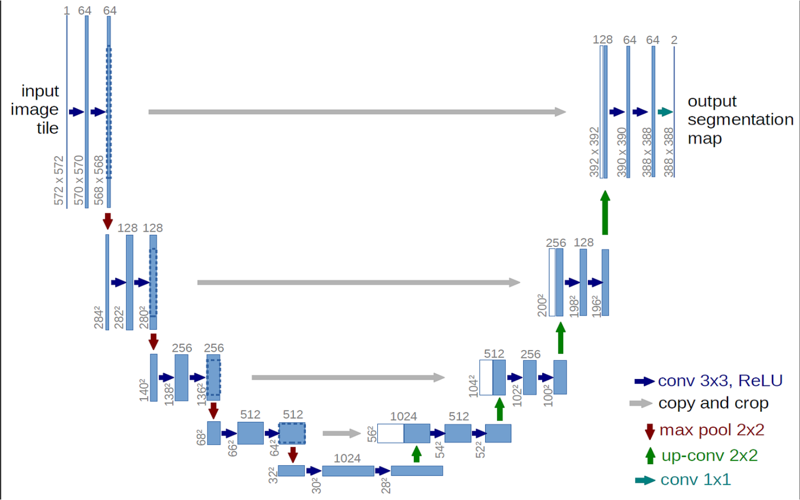

In [3]:
from PIL import Image

img=Image.open("/kaggle/input/archimage/arch.png")
img=img.resize((800,500))
img


<div style="text-align: center;">
    <strong><span style="color: Black;"><h2> Building the network from scratch</h2></span></strong>
</div>

In [4]:
class ConvBlock(nn.Module):
    def __init__(self,in_channels,out_channels):
        super(ConvBlock,self).__init__()
        self.conv=nn.Sequential(
        nn.Conv2d(in_channels,out_channels,kernel_size=3,padding=1,stride=1,bias=False),
        nn.BatchNorm2d(out_channels),
        nn.ReLU(inplace=True),
        
        nn.Conv2d(out_channels,out_channels,kernel_size=3,padding=1,stride=1,bias=False),
        nn.BatchNorm2d(out_channels),
        nn.ReLU(inplace=True)
        )
    def forward(self,x):
        return self.conv(x)


In [5]:
class UNET(nn.Module):
    def __init__(self,in_channels=3,out_channels=1,feature_maps=[64,128,256,512]):
        super(UNET,self).__init__()
        self.pool=nn.MaxPool2d(kernel_size=2,stride=2)
        self.downs,self.ups=nn.ModuleList(),nn.ModuleList()
        for feature_map in feature_maps:
            self.downs.append(ConvBlock(in_channels,feature_map))
            in_channels=feature_map
            
        self.bottom=ConvBlock(feature_maps[-1],feature_maps[-1]*2)

        
        for feature_map in reversed(feature_maps):
            self.ups.append(
                nn.ConvTranspose2d(feature_map*2,feature_map,kernel_size=2,stride=2)
            )
            self.ups.append(
                ConvBlock(feature_map*2,feature_map)
            )
        self.final=nn.Conv2d(feature_maps[0],out_channels,kernel_size=1)
#######################

    def forward(self,x):
        skip_connections=[]
        for down in self.downs:
            x=down(x)
            skip_connections.append(x)
            x=self.pool(x)
        x=self.bottom(x)
        skip_connections=skip_connections[::-1]
        for idx in range(0,len(self.ups),2):
            x=self.ups[idx](x)
            skip_connection=skip_connections[idx//2]
            
            if x.shape !=skip_connections[idx//2]:
                x=fn.resize(x,size=(skip_connection.shape[2:]))
                
            x=torch.cat((skip_connection,x),dim=1)
            x=self.ups[idx+1](x)
        return self.final(x)

##############


In [6]:
def test():
    x=torch.randn((3,1,160,160))
    model=UNET(in_channels=1,out_channels=1)
    preds=model(x)
    print(preds.shape)
    print(x.shape)
    assert preds.shape ==x.shape

In [7]:
test()

torch.Size([3, 1, 160, 160])
torch.Size([3, 1, 160, 160])



<div style="text-align: center;">
    <strong><span style="color: Black;"><h2> Getting data and building the datasets and dataloaders</h2></span></strong>
</div>

In [ ]:
!unzip /kaggle/input/carvana-image-masking-challenge/train.zip

Archive:  /kaggle/input/carvana-image-masking-challenge/train.zip
   creating: train/
  inflating: train/00087a6bd4dc_01.jpg  
  inflating: train/00087a6bd4dc_02.jpg  
  inflating: train/00087a6bd4dc_03.jpg  
  inflating: train/00087a6bd4dc_04.jpg  
  inflating: train/00087a6bd4dc_05.jpg  
  inflating: train/00087a6bd4dc_06.jpg  
  inflating: train/00087a6bd4dc_07.jpg  
  inflating: train/00087a6bd4dc_08.jpg  
  inflating: train/00087a6bd4dc_09.jpg  
  inflating: train/00087a6bd4dc_10.jpg  
  inflating: train/00087a6bd4dc_11.jpg  
  inflating: train/00087a6bd4dc_12.jpg  
  inflating: train/00087a6bd4dc_13.jpg  
  inflating: train/00087a6bd4dc_14.jpg  
  inflating: train/00087a6bd4dc_15.jpg  
  inflating: train/00087a6bd4dc_16.jpg  
  inflating: train/02159e548029_01.jpg  
  inflating: train/02159e548029_02.jpg  
  inflating: train/02159e548029_03.jpg  
  inflating: train/02159e548029_04.jpg  
  inflating: train/02159e548029_05.jpg  
  inflating: train/02159e548029_06.jpg  
  inflating:

In [ ]:
import os 

train_dir=os.listdir("/kaggle/working/train")
print(len(train_dir))

In [ ]:
abs_path="/kaggle/working/train"

In [ ]:
img=Image.open(os.path.join(abs_path,train_dir[0]))
img

In [ ]:
!unzip /kaggle/input/carvana-image-masking-challenge/train_masks.zip

In [ ]:
masks=os.listdir("/kaggle/working/train_masks")
img=Image.open(os.path.join("/kaggle/working/train_masks",train_dir[0].replace(".jpg","_mask.gif")))
img

In [ ]:
from torch.utils.data import Dataset,DataLoader
from torchvision.transforms import transforms,v2


In [ ]:
train_transform=A.Compose(
    [
        A.Resize(height=256, width=256),  
        A.HorizontalFlip(p=0.5),
        A.VerticalFlip(p=0.5),
        A.Rotate(limit=35,p=0.5),
        A.Normalize(
            mean=[0.0,0.0,0.0],
            std=[1.0,1.0,1.0],
            max_pixel_value=255.0
        ),
        ToTensorV2()
    ]
)

valid_transform=A.Compose(
    [
        A.Resize(height=256, width=256),  
        A.Normalize(
            mean=[0.0,0.0,0.0],
            std=[1.0,1.0,1.0],
            max_pixel_value=255.0
        ),
        ToTensorV2()
    ]
)

all_transform={
    "train_transform":train_transform,
    "valid_transform":valid_transform
}

In [ ]:
len(masks)

In [ ]:
randoms=np.random.choice(range(1, 5088), size=510, replace=False)

In [ ]:
target_dir="/kaggle/working/train_masks"
train_dir="/kaggle/working/train"
all_paths=os.listdir(train_dir)

In [ ]:
valid_paths=[all_paths[idx] for idx in randoms]


In [ ]:
train_paths = list(set(all_paths) - set(valid_paths))

In [ ]:
class Caravana(Dataset):
    def __init__(self, paths,x_dir, y_dir, transforms=None, is_train=True):
        self.x_dir = x_dir
        self.y_dir = y_dir
        self.transforms = transforms
        self.is_train = is_train
        
        # Get list of image paths
        self.x_paths = paths
     
        
    def __getitem__(self, index):
        # Load image and mask
        img_path=os.path.join(self.x_dir,self.x_paths[index])
        mask_path=os.path.join(self.y_dir,self.x_paths[index].replace(".jpg","_mask.gif"))
        # Convert to NumPy arrays
        img = np.array(Image.open(img_path).convert("RGB"))        
        target = np.array(Image.open(mask_path).convert('L'), dtype=np.float32)
        
        # Normalize mask values (255 -> 1.0)
        target[target == 255.0] = 1.0
        
   
       # print(img.shape,target.shape)
        if self.transforms is not None:
            if self.is_train:
                transformed = self.transforms["train_transform"](image=img, mask=target)
            else:
                transformed = self.transforms["valid_transform"](image=img, mask=target)
            
            # Extract transformed image and mask
            img = transformed["image"]
            target = transformed["mask"]
        
        return img, torch.unsqueeze(target,dim=0)
    
    def __len__(self):
        return len(self.x_paths)


In [ ]:
dataset=Caravana(train_paths,train_dir,target_dir,all_transform)

In [ ]:
train_loader=DataLoader(dataset,shuffle=True,batch_size=30)

In [ ]:
val_set=Caravana(valid_paths,train_dir,target_dir,all_transform,False)
val_loader=DataLoader(val_set,batch_size=30)

In [ ]:
x,y=dataset[0]

In [ ]:
x.shape,y.shape

In [ ]:
plt.imshow(x.permute(1,2,0))

In [ ]:
plt.imshow(y.permute(1,2,0))


<div style="text-align: center;">
    <strong><span style="color: Black;"><h2> Building the training loop and evaluation loop</h2></span></strong>
</div>

In [ ]:
model=UNET(in_channels=3,out_channels=1).to(device)
loss = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
scaler=torch.cuda.amp.GradScaler()

In [ ]:
def check_accuracy(loader,model):
    n_correct=0
    n_pixels=0
    dice_score=0
    model.eval()
    with torch.no_grad():
        for x,y in loader:
            x=x.to(device)
            y=y.to(device)
            preds=torch.sigmoid(model(x))
            preds=(preds>0.5).float()
            n_correct+=(preds==y).sum()
            n_pixels+=torch.numel(preds)
            
           # print(x.shape,y.shape,preds.shape)

            dice_score+=(2*(preds*y).sum())/((preds+y).sum())
    print(
        f"Got {n_correct} out of {n_pixels} true with accuracy {n_correct/n_pixels*100:.2f} and the dice score is {dice_score/len(loader)}"
    )
    model.train()

In [ ]:
def train_iter(loader,model,optimizer,loss,scaler):
    loop=tqdm(loader)
    for idx,(data,mask) in enumerate(loop):
        data=data.to(device)
        mask=mask.float().to(device)
        predictions=model(data)
       # print(predictions.shape,mask.shape)
        criterion=loss(predictions,mask)
        
        optimizer.zero_grad()
        scaler.scale(criterion).backward()
        scaler.step(optimizer)
        scaler.update()

        loop.set_postfix(loss=criterion.item())
    

In [ ]:
def train_epochs(n_epochs):
    for epoch in range(n_epochs):
        train_iter(train_loader,model,optimizer,loss,scaler)
        check_accuracy(val_loader,model)
        

train_epochs(5)

In [ ]:
train_epochs(5)

In [ ]:
test=next(iter(val_loader))

In [ ]:
x,y=test[0][:10],test[1][:10]

In [ ]:
x=x.to(device)
pred=model(x)

In [ ]:
x=x.to("cpu")
pred=pred.to("cpu")
pred=pred.detach()

### Displaying sample predictions

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(nrows=5, ncols=3, figsize=(25, 25))

for i in range(5):
    ax[i,0].imshow(x[i].permute(1, 2, 0))  
    ax[i,0].set_title("Image")
    ax[i,0].axis("off")  
    
    ax[i,1].imshow(pred[i].permute(1, 2, 0), cmap="gray") 
    ax[i,1].set_title("prediction")
    ax[i,1].axis("off")  
    
    ax[i,2].imshow(y[i].permute(1, 2, 0), cmap="gray") 
    ax[i,2].set_title("Mask")
    ax[i,2].axis("off")

plt.tight_layout()
plt.show()

<div style="text-align: center;">
    <strong><span style="color: Black;"><h2>Doaa Helal</h2></span></strong>
</div>